Cell 1 — Mount Drive + Unzip Dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip dataset
import zipfile, os

zip_path = '/content/drive/MyDrive/Leafly/leafly_data.zip'
extract_path = '/content/'

print("Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Done! Checking structure...")
os.listdir('/content/data/train')[:5]

Mounted at /content/drive
Unzipping dataset...
✅ Done! Checking structure...


['Pepper__bell___healthy',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_Late_blight',
 'Tomato_healthy']

📦 Cell 2 — Install timm + Check GPU

In [3]:
!pip install timm -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


📦 Cell 3 — Imports

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

# Add api module to path
sys.path.append('/content/drive/MyDrive/Leafly')  # Adjust path if needed

# Paths
TRAIN_DIR = '/content/data/train'
VAL_DIR   = '/content/data/val'
TEST_DIR  = '/content/data/test'

# Config
NUM_CLASSES  = 15
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10   # Phase 1: train head only
EPOCHS_FINE  = 10   # Phase 2: fine-tune
LR_HEAD      = 1e-3
LR_FINE      = 1e-4
IMG_SIZE     = 224
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")
print(f"Number of classes: {NUM_CLASSES}")

Using device: cuda
Number of classes: 15


📦 Cell 4 — Data Transforms + Loaders

In [ ]:
import cv2
from PIL import Image

# ===== PREPROCESSING PIPELINE =====
class LeafSegmentation:
    """
    Segment leaf from background using HSV color space.
    Handles green, yellow-green, and brownish/diseased leaves.
    """

    def __call__(self, img: Image.Image) -> Image.Image:
        img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        hsv   = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)

        # ── 1. Build mask: wider green + yellow-green range ──────────────
        lower_green1 = np.array([25,  30,  30])   # yellow-green
        upper_green1 = np.array([95, 255, 255])   # cyan-green
        mask = cv2.inRange(hsv, lower_green1, upper_green1)

        # ── 2. Morphological clean-up ─────────────────────────────────────
        kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,  5))

        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close, iterations=3)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel_open,  iterations=1)

        # ── 3. Keep only the largest contour (the leaf itself) ────────────
        mask = self._keep_largest_contour(mask)

        # ── 4. Fill interior holes (pale veins, bright spots) ────────────
        mask = self._fill_holes(mask)

        # ── 5. Smooth / feather edges ─────────────────────────────────────
        mask_blur = cv2.GaussianBlur(mask, (7, 7), 0)
        _, mask_clean = cv2.threshold(mask_blur, 127, 255, cv2.THRESH_BINARY)

        # ── 6. Compose result on white background ─────────────────────────
        result = img_cv.copy()
        result[mask_clean == 0] = [255, 255, 255]

        return Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

    # ── Helpers ───────────────────────────────────────────────────────────

    @staticmethod
    def _keep_largest_contour(mask: np.ndarray) -> np.ndarray:
        """Zero-out everything except the largest connected region."""
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return mask
        new_mask = np.zeros_like(mask)
        largest  = max(contours, key=cv2.contourArea)
        cv2.drawContours(new_mask, [largest], -1, 255, thickness=cv2.FILLED)
        return new_mask

    @staticmethod
    def _fill_holes(mask: np.ndarray) -> np.ndarray:
        """Flood-fill from border to find background, then invert."""
        flood = mask.copy()
        h, w  = flood.shape
        flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
        cv2.floodFill(flood, flood_mask, (0, 0), 255)
        holes = cv2.bitwise_not(flood)
        return cv2.bitwise_or(mask, holes)


class CLAHETransform:
    """
    Contrast Limited Adaptive Histogram Equalization.
    Applies CLAHE only to the L (lightness) channel in LAB color space,
    preserving full color information.
    """

    def __init__(self, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, img: Image.Image) -> Image.Image:
        """Apply CLAHE via LAB L-channel to preserve color."""

        # ── 1. Convert PIL → BGR → LAB ────────────────────────────────────
        img_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

        # ── 2. Split channels, apply CLAHE only to L (lightness) ─────────
        l, a, b = cv2.split(img_lab)
        l_clahe = self.clahe.apply(l)

        # ── 3. Merge back and convert to RGB ──────────────────────────────
        img_lab_clahe = cv2.merge((l_clahe, a, b))
        img_bgr_clahe = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2BGR)
        img_rgb_clahe = cv2.cvtColor(img_bgr_clahe, cv2.COLOR_BGR2RGB)

        return Image.fromarray(img_rgb_clahe)


# Training transforms: segmentation + resize + CLAHE + augmentation + normalize
train_transforms = transforms.Compose([
    LeafSegmentation(),                    # Step 1: Segment leaf (improved)
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Step 2: Resize
    CLAHETransform(),                      # Step 3: Enhance contrast (LAB L-channel)
    transforms.RandomHorizontalFlip(),     # Augmentation
    transforms.RandomRotation(15),         # Augmentation
    transforms.ColorJitter(brightness=0.3, contrast=0.3),  # Augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation/Test transforms: segmentation + resize + CLAHE + normalize (no augmentation)
val_transforms = transforms.Compose([
    LeafSegmentation(),                    # Step 1: Segment leaf (improved)
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Step 2: Resize
    CLAHETransform(),                      # Step 3: Enhance contrast (LAB L-channel)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Class names
class_names = train_dataset.classes
print(f"Classes ({len(class_names)}):", class_names)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("\n✅ Enhanced Preprocessing Pipeline:")
print("   1️⃣  Leaf Segmentation (improved: wider range, contour filtering, hole filling)")
print("   2️⃣  Image Resize (224×224)")
print("   3️⃣  CLAHE on LAB L-channel (preserves color, enhances contrast)")
print("   4️⃣  Augmentation (flip, rotation, color jitter) [TRAINING ONLY]")
print("   5️⃣  Normalize (ImageNet mean/std)")

Classes (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Train: 14439 | Val: 3089 | Test: 3109


📦 Cell 5 — Build Model

In [6]:
def build_model(num_classes, freeze_base=True):
    # Load pretrained EfficientNetB3
    model = timm.create_model('efficientnet_b3', pretrained=True)

    # Freeze all base layers
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head with our own
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )

    return model.to(DEVICE)

model = build_model(NUM_CLASSES, freeze_base=True)

# Verify only classifier head is trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Trainable params: 397,327 / 11,093,559


📦 Cell 6 — Training Function

In [7]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

📦 Cell 7 — Phase 1: Train Head Only

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD
)

best_val_acc = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("🔥 Phase 1: Training classification head...")
print("-" * 55)

for epoch in range(EPOCHS_HEAD):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = val_epoch(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'leafly_best.pth')
        print(f"Epoch {epoch+1:02d}/{EPOCHS_HEAD} | "
              f"Train Loss: {train_loss:.3f} Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.3f} Acc: {val_acc:.1f}% ✅ saved")
    else:
        print(f"Epoch {epoch+1:02d}/{EPOCHS_HEAD} | "
              f"Train Loss: {train_loss:.3f} Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.3f} Acc: {val_acc:.1f}%")

print(f"\n✅ Phase 1 complete. Best Val Acc: {best_val_acc:.1f}%")

🔥 Phase 1: Training classification head...
-------------------------------------------------------
Epoch 01/10 | Train Loss: 0.857 Acc: 73.3% | Val Loss: 0.474 Acc: 85.3% ✅ saved
Epoch 02/10 | Train Loss: 0.498 Acc: 83.7% | Val Loss: 0.435 Acc: 87.4% ✅ saved
Epoch 03/10 | Train Loss: 0.446 Acc: 85.1% | Val Loss: 0.329 Acc: 90.8% ✅ saved
Epoch 04/10 | Train Loss: 0.418 Acc: 85.7% | Val Loss: 0.323 Acc: 89.5%
Epoch 05/10 | Train Loss: 0.386 Acc: 87.0% | Val Loss: 0.332 Acc: 90.0%
Epoch 06/10 | Train Loss: 0.360 Acc: 87.7% | Val Loss: 0.367 Acc: 90.8%
Epoch 07/10 | Train Loss: 0.353 Acc: 87.5% | Val Loss: 0.277 Acc: 90.9% ✅ saved
Epoch 08/10 | Train Loss: 0.337 Acc: 88.7% | Val Loss: 0.272 Acc: 91.9% ✅ saved
Epoch 09/10 | Train Loss: 0.320 Acc: 89.0% | Val Loss: 0.314 Acc: 90.4%
Epoch 10/10 | Train Loss: 0.321 Acc: 89.0% | Val Loss: 0.251 Acc: 92.0% ✅ saved

✅ Phase 1 complete. Best Val Acc: 92.0%


📦 Cell 8 — Phase 2: Fine-Tuning

In [1]:
# Unfreeze last 3 blocks of EfficientNetB3
def unfreeze_last_blocks(model, num_blocks=3):
    blocks = list(model.blocks.children())
    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    # Always unfreeze head
    for param in model.classifier.parameters():
        param.requires_grad = True

unfreeze_last_blocks(model, num_blocks=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {trainable:,}")

# Lower LR for fine-tuning
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE
)

print("\n🔥 Phase 2: Fine-tuning last 3 blocks...")
print("-" * 55)

for epoch in range(EPOCHS_FINE):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = val_epoch(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'leafly_best.pth')
        print(f"Epoch {epoch+1:02d}/{EPOCHS_FINE} | "
              f"Train Loss: {train_loss:.3f} Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.3f} Acc: {val_acc:.1f}% ✅ saved")
    else:
        print(f"Epoch {epoch+1:02d}/{EPOCHS_FINE} | "
              f"Train Loss: {train_loss:.3f} Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.3f} Acc: {val_acc:.1f}%")

print(f"\n✅ Phase 2 complete. Best Val Acc: {best_val_acc:.1f}%")

NameError: name 'model' is not defined

📦 Cell 9 — Plot Training Curves

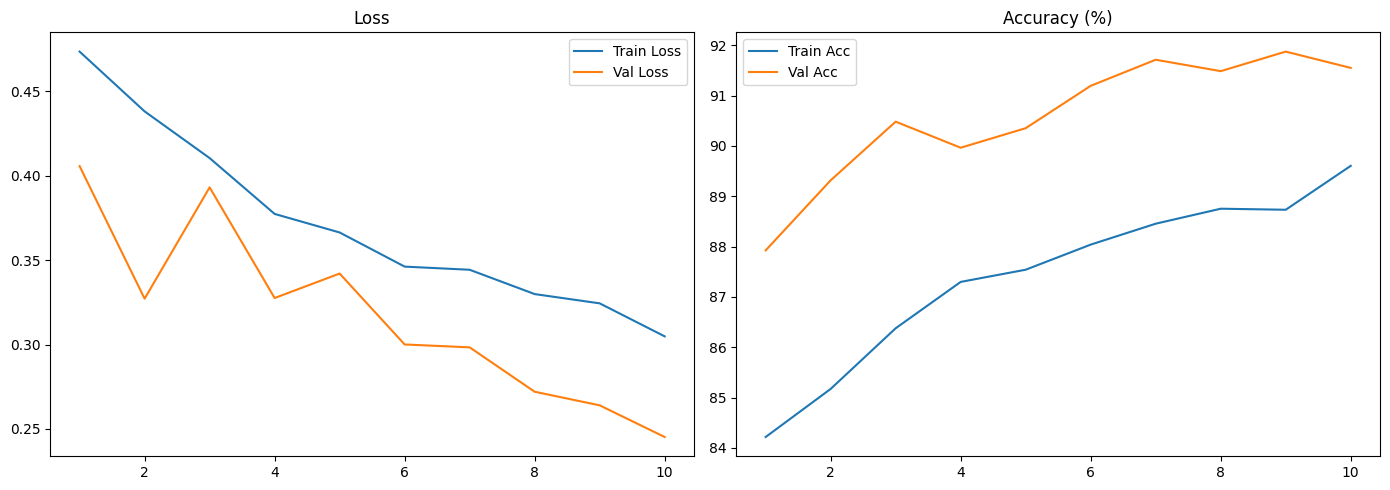

✅ Plot saved


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy (%)'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print("✅ Plot saved")

📦 Cell 10 — Final Test Evaluation + Save to Drive

In [ ]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('leafly_best.pth'))
test_loss, test_acc = val_epoch(model, test_loader, criterion)
print(f"🎯 Final Test Accuracy: {test_acc:.2f}%")

# Save model + class names to Drive
import json, shutil

# Save class names
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# Copy to Drive
drive_save = '/content/drive/MyDrive/Leafly/'
shutil.copy('leafly_best.pth',       drive_save + 'leafly_model.pth')
shutil.copy('class_names.json',      drive_save + 'class_names.json')
shutil.copy('training_curves.png',   drive_save + 'training_curves.png')

print("✅ Model saved to Google Drive!")
print(f"   → {drive_save}leafly_model.pth")
print(f"   → {drive_save}class_names.json")

🎯 Final Test Accuracy: 91.83%
✅ Model saved to Google Drive!
   → /content/drive/MyDrive/Leafly/leafly_model.pth
   → /content/drive/MyDrive/Leafly/class_names.json
